<a href="https://colab.research.google.com/github/rsyadipras/PCVK_Ganjil2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# **Transformasi Linier Brightness**

Formula: g(x,y) = f(x,y)+b
g(x,y) adlaah nilai pixel setelah transformasi, f(x,y) adalah nilai pixel asli, b adalah nilai brightness

In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 30


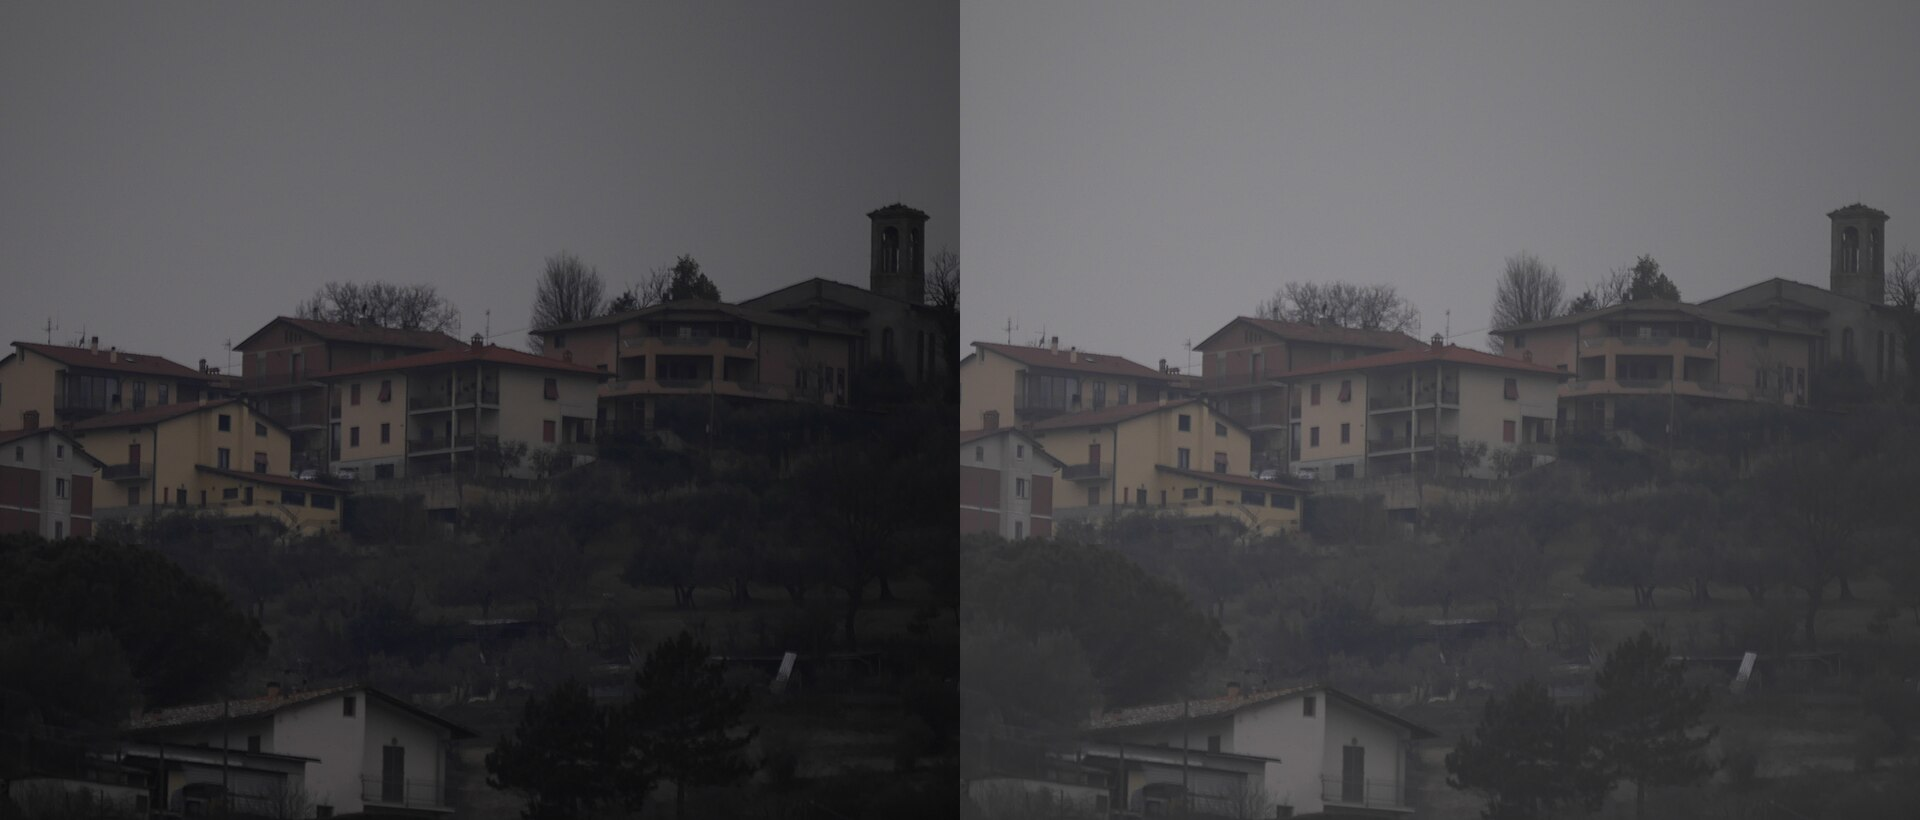

In [ ]:
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

# Sesuaikan dengan file dan folder di drive anda
original = cv.imread('/content/drive/MyDrive/PCVK2026/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

# akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

# Cara simple tanpa loop
# brightness_image = cv.convertScaleAbs(original, beta=brightness)
final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

# **TUGAS PRAKTIKUM**

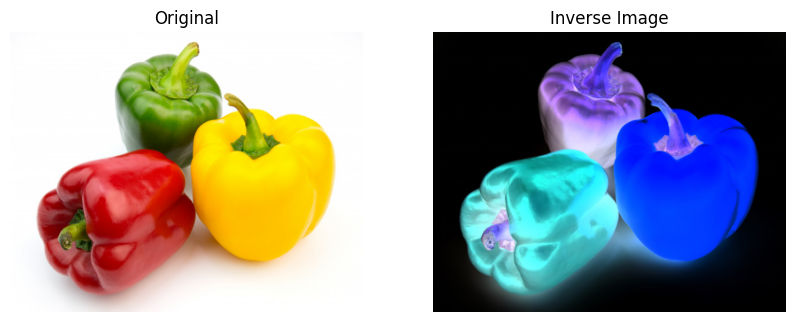

In [ ]:
# Implementasi inversi citra pada google colab

img = io.imread('/content/drive/MyDrive/PCVK2026/peppers.jpg')
img_inverse = 255 - img

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_inverse)
axes[1].set_title('Inverse Image')
axes[1].axis('off')
plt.show()

Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


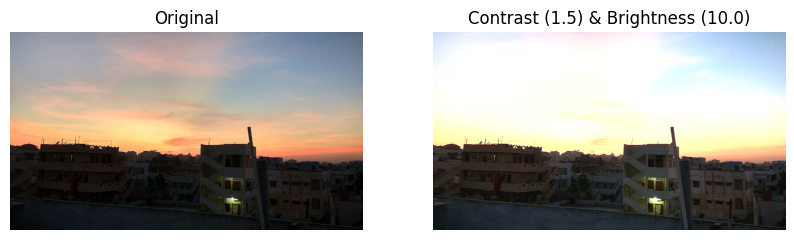

In [ ]:
# Implementasi transformasi contrast pada google colab

try:
  b = float(input('Masukkan tingkat kecerahan: '))
  a = float(input('Masukkan kontras: '))
except ValueError:
  print('Error, not a number. Menggunakan nilai default (brightness = 0, contrast = 1.0)')
  b = 0.0
  a = 1.0

img = io.imread('/content/drive/MyDrive/PCVK2026/sunset.jpg')

img_contrast = np.clip(a * img.astype(np.float32) + b, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_contrast)
axes[1].set_title(f'Contrast ({a}) & Brightness ({b})')
axes[1].axis('off')
plt.show()

Masukkan nilai kecerahan: 50


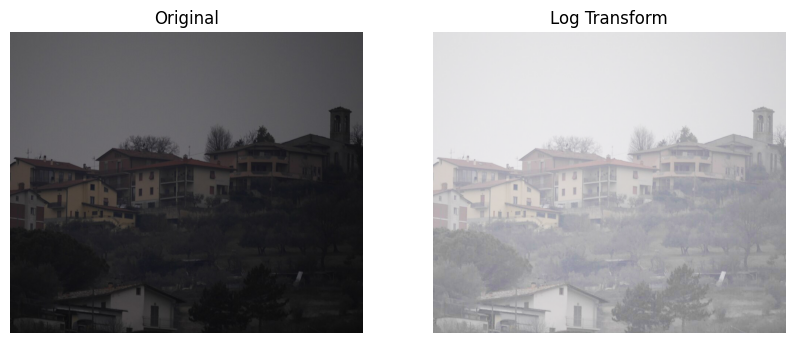

In [ ]:
# Implementasi transformasi logarithmic brightness pada google colab

try:
  c = float(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number. Menggunakan nilai default (c = 10)')
  c = 10

img = io.imread('/content/drive/MyDrive/PCVK2026/houses.jpg')

img_log = c * (np.log(1 + img.astype(np.float32)))
img_log = np.clip(img_log, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_log)
axes[1].set_title('Log Transform')
axes[1].axis('off')
plt.show()

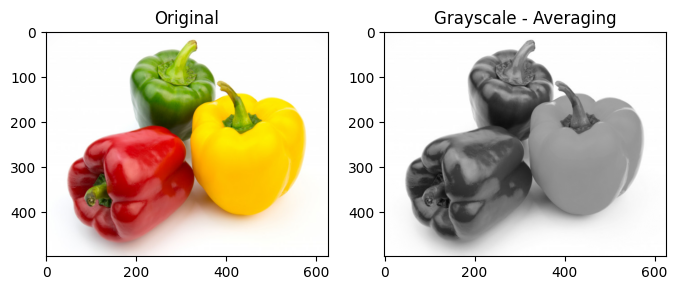

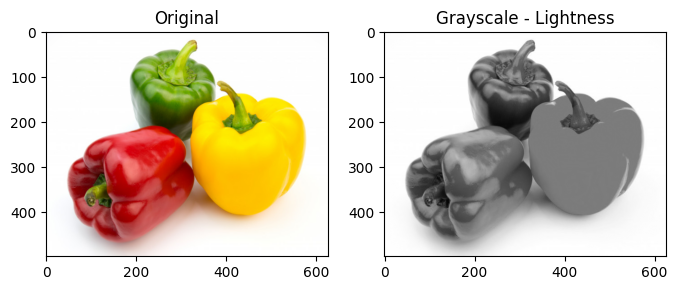

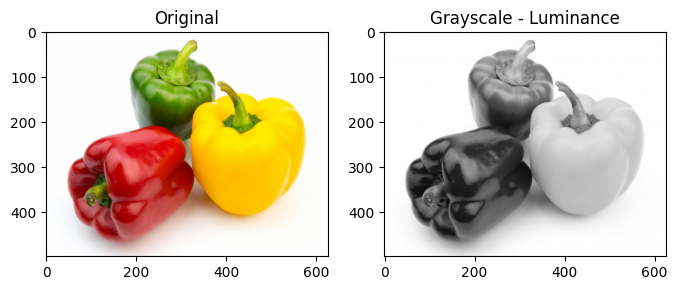

In [ ]:
# Impelemtasi transformasi grayscale metode averaging, lightness, luminance
img = io.imread('/content/drive/MyDrive/PCVK2026/peppers.jpg')
R, G, B = img[:,:,0].astype(float), img[:,:,1].astype(float), img[:,:,2].astype(float)

# Formula Grayscale
gray_avg = ((R + G + B) / 3).astype(np.uint8)
gray_light = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)
gray_lum = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

methods = [('Averaging', gray_avg), ('Lightness', gray_light), ('Luminance', gray_lum)]
for name, gray_img in methods:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title('Original')
    axes[1].imshow(gray_img, cmap='gray')
    axes[1].set_title(f'Grayscale - {name}')
    plt.show()

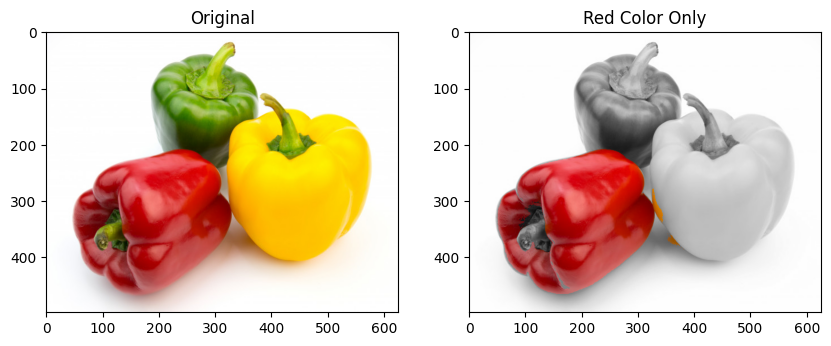

In [ ]:
# Implementasi tampilkan warna tertentu, yang lain grayscale
img = io.imread('/content/drive/MyDrive/PCVK2026/peppers.jpg')
R, G, B = img[:,:,0].astype(float), img[:,:,1].astype(float), img[:,:,2].astype(float)

gray = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8) # grayscale luminance
red_mask = (R > 100) & (R > G * 1.7) & (R > B * 1.2) # menampilkan warna merah saja

result = np.zeros_like(img)
for c in range(3):
    result[:,:,c] = np.where(red_mask, img[:,:,c], gray)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[1].imshow(result)
axes[1].set_title('Red Color Only')
plt.show()

Gamma Correction pada Citra
--------------------------------
Masukkan nilai Gamma: 0.5


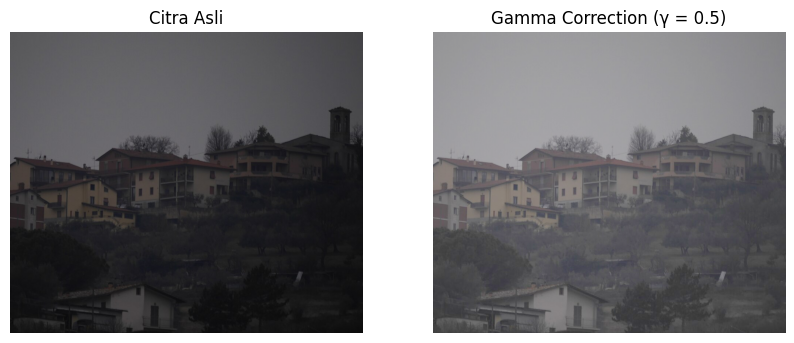

In [ ]:
# Implementasi Gamma Correction

print('Gamma Correction pada Citra')
print('--------------------------------')
try:
  gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
  print('Error, not a number')

img = io.imread('/content/drive/MyDrive/PCVK2026/houses.jpg')


gamma_corrected = np.array(255 * (img / 255.0) ** gamma, dtype=np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title('Citra Asli')
axes[0].axis('off')

axes[1].imshow(gamma_corrected)
axes[1].set_title(f'Gamma Correction (γ = {gamma})')
axes[1].axis('off')
plt.show()

Masukkan bit depth tujuan (1-7): 3


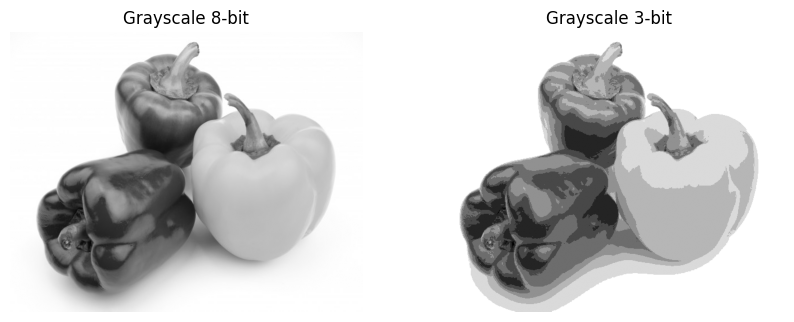

In [ ]:
# Implementasi Simulasi Image Depth
bit_depth = int(input('Masukkan bit depth tujuan (1-7): '))
original = cv.imread('/content/drive/MyDrive/PCVK2026/peppers.jpg', cv.IMREAD_GRAYSCALE)

level = 255 / (pow(2, bit_depth) - 1)
depth_image = (np.round(original / level) * level).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original, cmap='gray')
axes[0].set_title('Grayscale 8-bit')
axes[0].axis('off')

axes[1].imshow(depth_image, cmap='gray')
axes[1].set_title(f'Grayscale {bit_depth}-bit')
axes[1].axis('off')
plt.show()

Jumlah Citra: 10 | PSNR: 19.74 dB
Jumlah Citra: 20 | PSNR: 19.84 dB
Jumlah Citra: 40 | PSNR: 19.89 dB
Jumlah Citra: 80 | PSNR: 19.92 dB
Jumlah Citra: 100 | PSNR: 19.92 dB


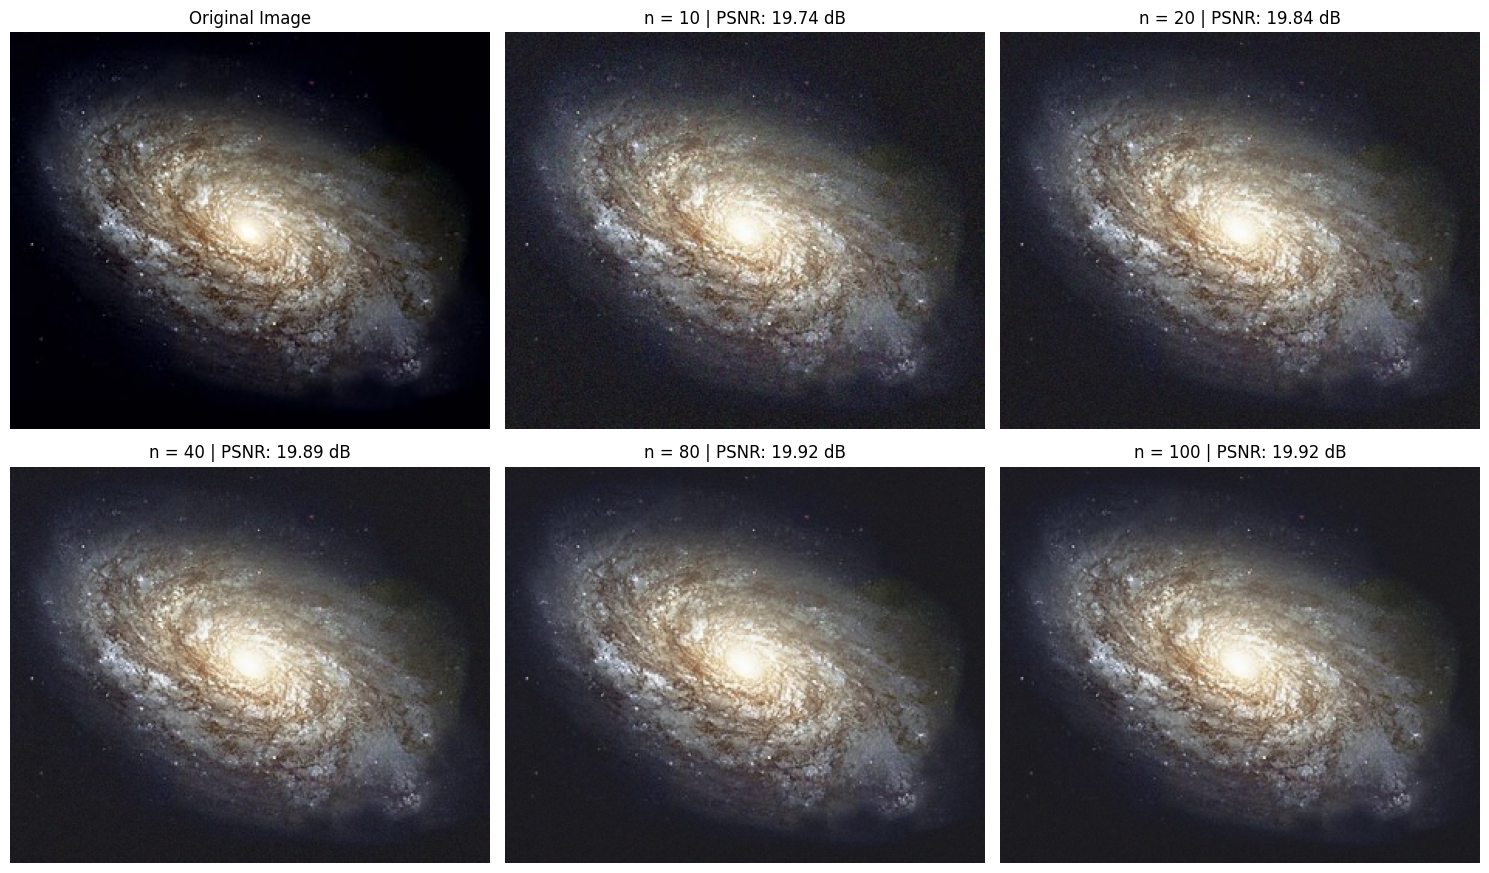

In [4]:
import glob, math

def PSNR(img1, img2):
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    if mse == 0: return 100
    return 20 * math.log10(255.0 / math.sqrt(mse))

# Load citra
orig_img = cv.imread('/content/drive/MyDrive/PCVK2026/galaxy.jpg')
noise_files = sorted(glob.glob('/content/drive/MyDrive/PCVK2026/noises/*.jpg'))
noisy_imgs = [cv.imread(f) for f in noise_files]

# Konversi gambar asli ke RGB untuk visualisasi Matplotlib
orig_img_rgb = cv.cvtColor(orig_img, cv.COLOR_BGR2RGB)

n_values = [10, 20, 40, 80, 100]

# Ukuran kanvas visualisasi (2 baris, 3 kolom)
plt.figure(figsize=(15, 9))

# Tampilkan gambar asli
plt.subplot(2, 3, 1)
plt.imshow(orig_img_rgb)
plt.title("Original Image")
plt.axis('off')

# Loop perhitungan PSNR dan plotting gambar
for idx, n in enumerate(n_values, start=2):
    avg_img = np.mean(noisy_imgs[:n], axis=0).astype(np.uint8)
    psnr_val = PSNR(orig_img, avg_img)

    # Cetak nilai PSNR pada konsol
    print(f"Jumlah Citra: {n} | PSNR: {psnr_val:.2f} dB")

    # Konversi citra averaging ke RGB
    avg_img_rgb = cv.cvtColor(avg_img, cv.COLOR_BGR2RGB)

    # Plot citra pada subplot
    plt.subplot(2, 3, idx)
    plt.imshow(avg_img_rgb)
    plt.title(f"n = {n} | PSNR: {psnr_val:.2f} dB")
    plt.axis('off')

plt.tight_layout()
plt.show()